In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load the dataset
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic EDA
print("Shape:", df.shape)
print("Missing Values:\n\n", df.isna().sum())

Shape: (20640, 9)
Missing Values:

 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


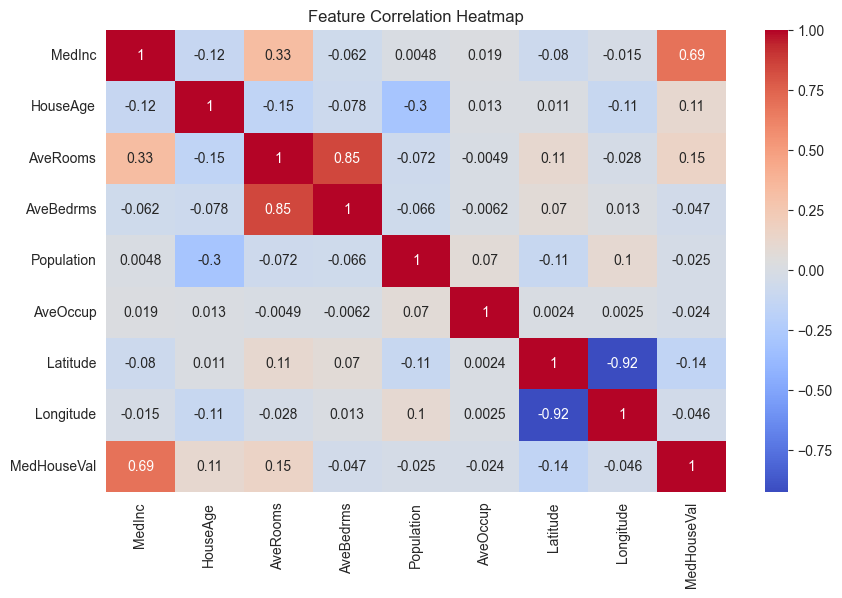

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

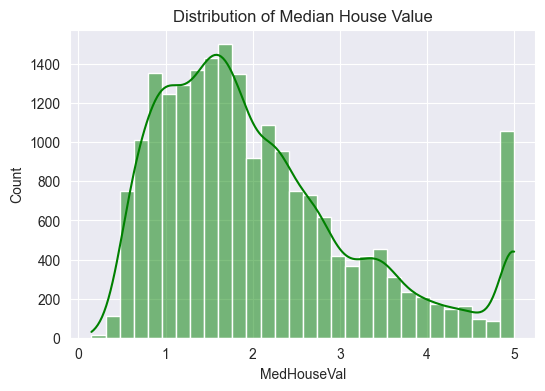

In [5]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["MedHouseVal"], kde=True, bins=30, color="green")
plt.title("Distribution of Median House Value")
plt.show()

In [6]:
# Split the data
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Define base regressors and meta-model
base_models = [
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("gb", GradientBoostingRegressor(random_state=42)),
    ("lr", LinearRegression())
]

In [9]:
meta_model = LinearRegression()

In [10]:
# Building Stacking Regressor
stacking_model = StackingRegressor(estimators = base_models, final_estimator=meta_model, n_jobs=-1)

In [11]:
# Train and evaluate
stacking_model.fit(X_train_scaled, y_train)

,estimators,"[('rf', ...), ('gb', ...), ...]"
,final_estimator,LinearRegression()
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [12]:
# Prediction
y_pred = stacking_model.predict(X_test_scaled)
y_pred

array([0.45178692, 0.77486729, 4.85388241, ..., 4.80105017, 0.69872221,
       1.73029625], shape=(4128,))

In [13]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_absolute_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.32710340949891736
RMSE: 0.5719295494192597
R2 Score: 0.807880952280216


# Compare Models

In [14]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42)),
    ("Stacking Regressor", stacking_model)
]

In [15]:
results = {}
for name, model in models:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = r2_score(y_test, preds)

C:\Users\muham\AppData\Local\Temp\ipykernel_28808\3291341989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


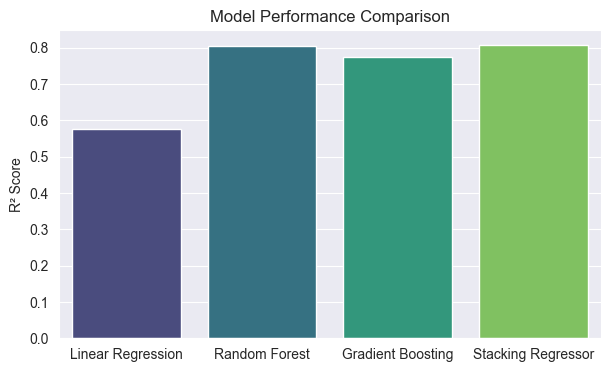

In [16]:
# Visualization of comparison
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

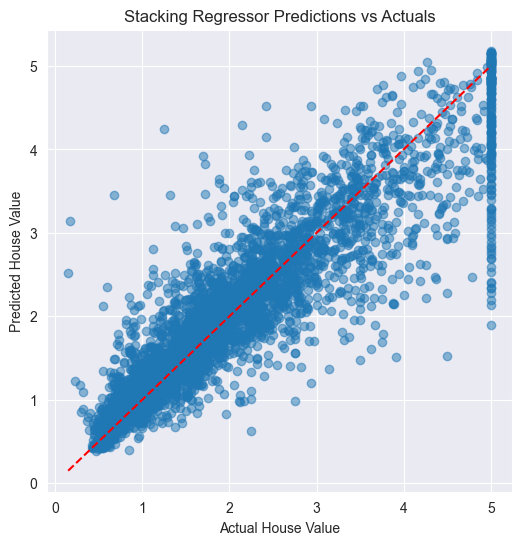

In [17]:
# Scatter plot of predicted vs actual values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Stacking Regressor Predictions vs Actuals")
plt.show()